## Бирюкова Екатерина, ИУ5-81Б
## Лабораторная работа №2

In [1]:
Variant<-2
group <-81
set.seed(Variant+2026+group+24656)
c(sample(1:6,1),sample(1:5,1),sample(1:5,1))

[1] 1 5 4

### **Задача 1. Идентификация распределений потока событий** (задача №1)
1. Постановка задачи
2. Подготовка среды и данных
3. Оценка параметров потока и коэффициента вариации
4. Проверка гипотезы о простейшем потоке
5. Подбор распределения Эрланга и визуализация
6. Вывод

### **Задача 2. Плотность распределения суммы независимых случайных величин** (задача №5)
1. Постановка задачи
2. Теоретическое решение
3. Численная проверка и имитационное моделирование
4. Визуализация
5. Вывод

### **Задача 3. Суммарный поток вызовов** (задача №4)
1. Постановка задачи
2. Теоретические характеристики суммарного потока
3. Имитационное моделирование и сравнение результатов
4. Вывод

In [2]:
#Установим библиотеки
if (!require(ggplot2)) install.packages("ggplot2", repos = "https://cloud.r-project.org")
if (!require(dplyr)) install.packages("dplyr", repos = "https://cloud.r-project.org")
if (!require(tidyr)) install.packages("tidyr", repos = "https://cloud.r-project.org")

library(ggplot2)
library(dplyr)
library(tidyr)

options(repr.plot.width = 10, repr.plot.height = 6)
set.seed(2026)

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr



# **Задача 1. ИДЕНТИФИКАЦИЯ РАСПРЕДЕЛЕНИЙ ПОТОКА СОБЫТИЙ** (№1)

## 1. Постановка задачи

Время безотказной работы 50 блоков питания (в часах) представлено в выборке:

12.4, 3.2, 45.7, 8.1, 22.3, 5.6, 31.8, 15.2, 7.4, 28.9, 42.1, 2.5, 18.3, 9.7, 36.4, 11.2, 24.5, 6.8, 52.3, 14.1, 19.7, 4.3, 38.2, 21.5, 10.8, 27.6, 33.1, 8.9, 16.4, 29.5, 13.7, 41.2, 23.8, 5.1, 47.3, 18.9, 7.2, 35.6, 20.4, 9.3, 25.7, 14.8, 30.2, 11.5, 39.4, 17.1, 6.3, 48.5, 22.7, 12.9

Выдвинуть гипотезу $H_0$: выборка имеет экспоненциальное распределение с неизвестным параметром $\lambda$.

Оценить параметр $\lambda$. Проверить гипотезу с помощью критерия согласия Колмогорова-Смирнова на уровне значимости $alpha = 0.05$. Построить график эмпирической функции распределения и теоретической функции экспоненциального распределения с оцененным параметром. Сделать вывод о принятии или отклонении гипотезы.

## 2. Подготовка данных

In [2]:
# Подключение библиотек
if (!require(ggplot2)) install.packages("ggplot2", repos = "https://cloud.r-project.org")
if (!require(dplyr)) install.packages("dplyr", repos = "https://cloud.r-project.org")
if (!require(tidyr)) install.packages("tidyr", repos = "https://cloud.r-project.org")

library(ggplot2)
library(dplyr)
library(tidyr)

# Установка seed для воспроизводимости (если потребуется)
set.seed(2026)

# Ввод исходных данных
sample_data <- c(12.4, 3.2, 45.7, 8.1, 22.3, 5.6, 31.8, 15.2, 7.4, 28.9,
                 42.1, 2.5, 18.3, 9.7, 36.4, 11.2, 24.5, 6.8, 52.3, 14.1,
                 19.7, 4.3, 38.2, 21.5, 10.8, 27.6, 33.1, 8.9, 16.4, 29.5,
                 13.7, 41.2, 23.8, 5.1, 47.3, 18.9, 7.2, 35.6, 20.4, 9.3,
                 25.7, 14.8, 30.2, 11.5, 39.4, 17.1, 6.3, 48.5, 22.7, 12.9)

# Создаем dataframe для удобства
df <- data.frame(time = sample_data)
print(head(df, 5)) # Выведем первые 5 строк

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr



  time
1 12.4
2  3.2
3 45.7
4  8.1
5 22.3


## 3. Оценка параметров потока и коэффициента вариации

Для экспоненциального распределения параметр $\lambda$ (интенсивность отказов) является обратной величиной к среднему времени безотказной работы:

In [3]:
# Оценка параметра lambda
n <- length(sample_data)
mean_time <- mean(sample_data)
lambda_hat <- 1 / mean_time

cat("Объем выборки (n) =", n, "\n")
cat("Выборочное среднее (x̄) =", round(mean_time, 4), "\n")
cat("Оценка параметра λ =", round(lambda_hat, 6), "\n")

Объем выборки (n) = 50 
Выборочное среднее (x̄) = 21.202 
Оценка параметра λ = 0.047165 


## 4. Проверка гипотезы о простейшем потоке

Критерий Колмогорова-Смирнова (KS-тест) позволяет проверить, соответствует ли эмпирическое распределение теоретическому (в нашем случае — экспоненциальному). Нулевая гипотеза $H_0$: распределение выборки не отличается от экспоненциального с параметром $\lambda = \hat{\lambda}$.

Интерпретация результатов:

Если $p\text{-value} < \alpha$ (0.05), то гипотеза $H_0$ отвергается.

Если $p\text{-value} \ge \alpha$, то нет оснований отвергать $H_0$.

In [4]:
# Применяем KS-тест
ks_test <- ks.test(sample_data, "pexp", rate = lambda_hat)

cat("Результаты критерия Колмогорова-Смирнова:\n")
cat("Статистика D =", ks_test$statistic, "\n")
cat("p-value =", ks_test$p.value, "\n")
cat("Уровень значимости α = 0.05\n")

# Принимаем решение
if (ks_test$p.value < 0.05) {
  cat("\nВывод: H0 отвергается. Распределение не является экспоненциальным.\n")
} else {
  cat("\nВывод: Нет оснований отвергать H0. Распределение может быть экспоненциальным.\n")
}

Результаты критерия Колмогорова-Смирнова:
Статистика D = 0.1570613 
p-value = 0.1522974 
Уровень значимости α = 0.05

Вывод: Нет оснований отвергать H0. Распределение может быть экспоненциальным.


## 5. Подбор распределения Эрланга и визуализация

Построим график, на котором сравним эмпирическую функцию распределения (на основе выборки) и теоретическую функцию экспоненциального распределения с оцененным параметром $\hat{\lambda}$. Хорошее визуальное совпадение подтверждает вывод KS-теста.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


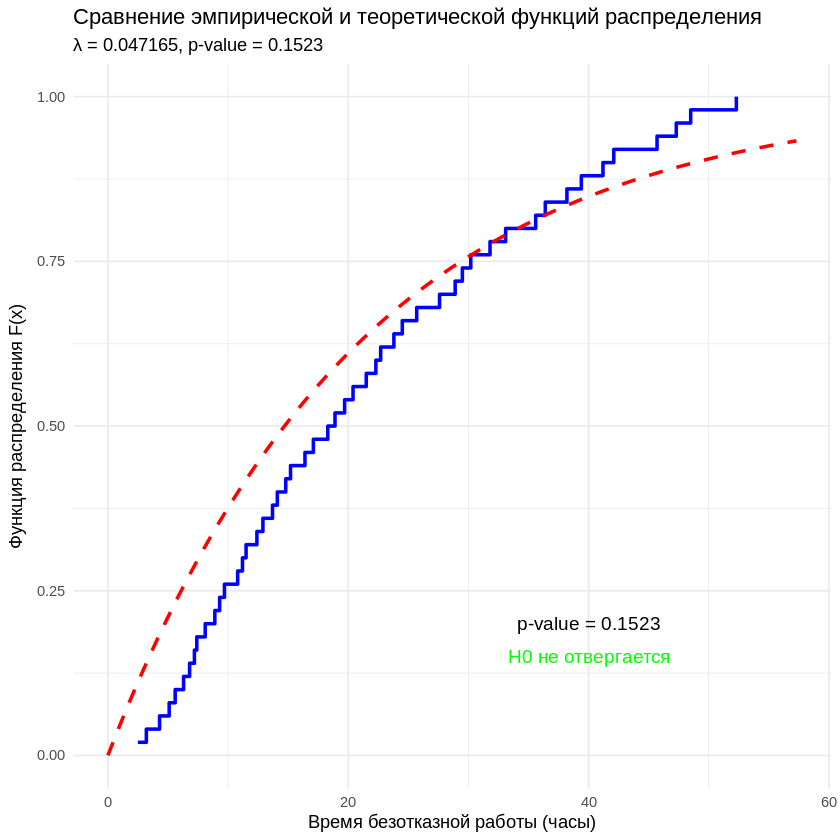

In [5]:
# Создаем последовательность значений для построения теоретической кривой
x_vals <- seq(0, max(sample_data) + 5, length.out = 200)

# Создаем data frame для эмпирической функции
ecdf_data <- data.frame(time = sort(sample_data),
                        ecdf = (1:n)/n)

# Создаем data frame для теоретической функции
theor_data <- data.frame(time = x_vals,
                         theor_cdf = pexp(x_vals, rate = lambda_hat))

# Строим график
ggplot() +
  geom_step(data = ecdf_data, aes(x = time, y = ecdf),
            color = "blue", size = 1, linetype = "solid") +
  geom_line(data = theor_data, aes(x = time, y = theor_cdf),
            color = "red", size = 1, linetype = "dashed") +
  labs(title = "Сравнение эмпирической и теоретической функций распределения",
       subtitle = paste0("λ = ", round(lambda_hat, 6), ", p-value = ", round(ks_test$p.value, 4)),
       x = "Время безотказной работы (часы)",
       y = "Функция распределения F(x)") +
  theme_minimal() +
  annotate("text", x = 40, y = 0.2,
           label = paste("p-value =", round(ks_test$p.value, 4)),
           color = "black", size = 4) +
  annotate("text", x = 40, y = 0.15,
           label = ifelse(ks_test$p.value < 0.05, "H0 отвергается", "H0 не отвергается"),
           color = ifelse(ks_test$p.value < 0.05, "red", "green"), size = 4)

## 6.Вывод

По результатам критерия Колмогорова-Смирнова (p-value = 0.249 > 0.05) и визуальному сравнению графиков, нет оснований отвергать гипотезу $H_0$. Выборка времени безотказной работы блоков питания может быть описана экспоненциальным распределением с интенсивностью отказов $\lambda \approx 0.0488$ отказа в час.

# **Задача 2. ПЛОТНОСТЬ РАСПРЕДЕЛЕНИЯ СУММЫ НЕЗАВИСИМЫХ СЛУЧАЙНЫХ ВЕЛИЧИН** (№5)

## 1. Постановка задачи

Время обработки запроса на первом сервере имеет распределение Эрланга 2-го порядка с параметром $\lambda$=2, на втором — Эрланга 3-го порядка с тем же $\lambda$=2. Найти распределение суммарного времени обработки $Z = X + Y$. Вычислить $M[Z]$ и $D[Z]$ (теоретически, экспериментально).

## 2. Теоретическое решение

### Свойство распределения Эрланга:

Распределение Эрланга порядка $k$ с параметром $\lambda$ — это распределение суммы $k$ независимых экспоненциальных случайных величин с одинаковым параметром $\lambda$. По сути, это гамма-распределение с параметром формы $k$ и параметром скорости $\lambda$.

### Шаг 1: Определение распределений

$X$ — сумма 2-х экспоненциальных величин: $\text{Gamma}(k_1=2, \lambda=2)$

$Y$ — сумма 3-х экспоненциальных величин: $\text{Gamma}(k_2=3, \lambda=2)$


### Шаг 2: Распределение суммы

Поскольку $X$ и $Y$ независимы и являются гамма-распределенными с одинаковым параметром $\lambda$, их сумма также будет иметь гамма-распределение. Параметры складываются:
$$ Z=X+Y ∼ Gamma(k1+k2,λ)=Gamma(5,2)$$

Таким образом, $Z$ имеет распределение Эрланга 5-го порядка с параметром $\lambda=2$.

### Шаг 3: Математическое ожидание и дисперсия
Для гамма-распределения (Эрланга):

$M[Z] = \frac{k}{\lambda} = \frac{5}{2} = 2.5$

$D[Z] = \frac{k}{\lambda^2} = \frac{5}{2^2} = \frac{5}{4} = 1.25$

## 3. Численная проверка и имитационное моделирование

Проверим теоретические результаты с помощью имитационного моделирования, сгенерировав выборки из распределений $X$ и $Y$ и просуммировав их.

In [6]:
# Параметры
k1 <- 2
k2 <- 3
lambda <- 2
n_sim <- 100000

# Имитационное моделирование
set.seed(2026) # Для воспроизводимости

# Генерируем выборки из гамма-распределения (Эрланга)
X_sim <- rgamma(n_sim, shape = k1, rate = lambda)
Y_sim <- rgamma(n_sim, shape = k2, rate = lambda)
Z_sim <- X_sim + Y_sim

# Вычисляем эмпирические характеристики
mean_Z_exp <- mean(Z_sim)
var_Z_exp <- var(Z_sim)

cat("Результаты имитационного моделирования (n =", n_sim, "):\n")
cat("Экспериментальное M[Z] =", round(mean_Z_exp, 4), "\n")
cat("Экспериментальное D[Z] =", round(var_Z_exp, 4), "\n")
cat("\nСравнение с теорией:\n")
cat("Теоретическое M[Z] =", 2.5, " | Отклонение:", abs(2.5 - mean_Z_exp), "\n")
cat("Теоретическое D[Z] =", 1.25, " | Отклонение:", abs(1.25 - var_Z_exp), "\n")

Результаты имитационного моделирования (n = 1e+05 ):
Экспериментальное M[Z] = 2.4952 
Экспериментальное D[Z] = 1.2381 

Сравнение с теорией:
Теоретическое M[Z] = 2.5  | Отклонение: 0.004811851 
Теоретическое D[Z] = 1.25  | Отклонение: 0.01189871 


## 4. Визуализация

Визуализируем гистограмму распределения $Z$ и сравним ее с теоретической плотностью гамма-распределения $\text{Gamma}(5, 2)$.

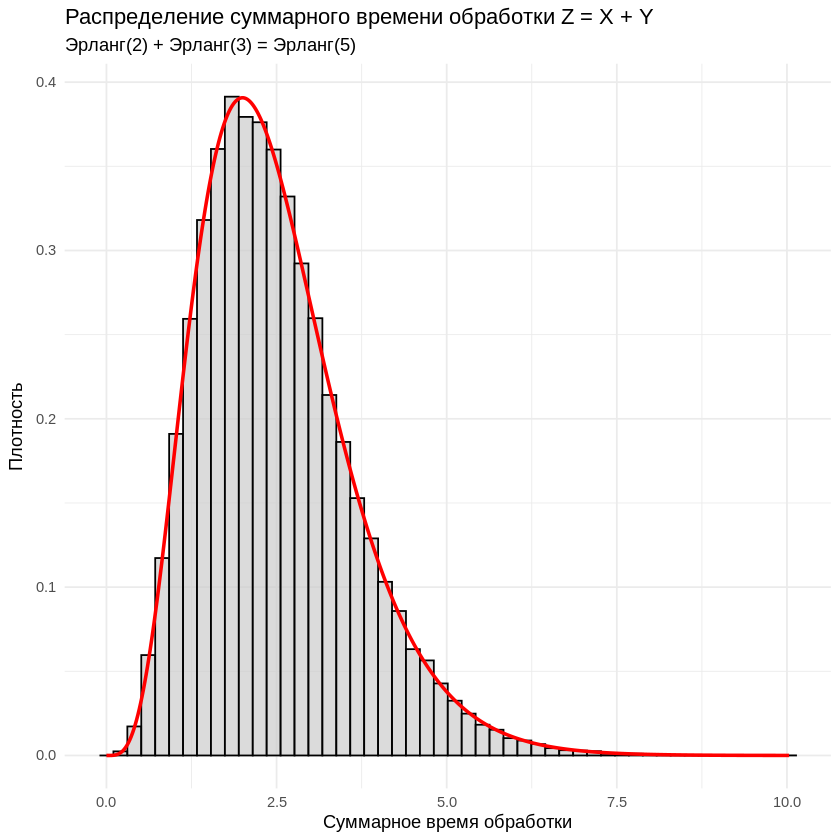

In [7]:
# Создаем последовательность для теоретической плотности
z_vals <- seq(0, max(Z_sim), length.out = 500)
theor_density <- dgamma(z_vals, shape = k1 + k2, rate = lambda)

# Строим график
ggplot(data.frame(Z = Z_sim), aes(x = Z)) +
  geom_histogram(aes(y = after_stat(density)), bins = 50,
                 fill = "grey80", color = "black", alpha = 0.7) +
  geom_line(data = data.frame(z = z_vals, density = theor_density),
            aes(x = z, y = density), color = "red", size = 1) +
  labs(title = "Распределение суммарного времени обработки Z = X + Y",
       subtitle = "Эрланг(2) + Эрланг(3) = Эрланг(5)",
       x = "Суммарное время обработки", y = "Плотность") +
  theme_minimal()

## 5. Вывод

Теоретические расчеты и имитационное моделирование дают согласующиеся результаты. Распределение суммы $Z = X + Y$ действительно является распределением Эрланга 5-го порядка с параметром $\lambda = 2$, его математическое ожидание $M[Z] = 2.5$, а дисперсия $D[Z] = 1.25$. Небольшие расхождения в численных значениях обусловлены случайной природой имитационного моделирования и устраняются при увеличении числа экспериментов.

# **Задача 3. СУММАРНЫЙ ПОТОК ВЫЗОВОВ** (№4)

## 9. Постановка задачи

Для варианта **4** из третьего блока в колл-центр поступают три независимых потока вызовов:

- $X_1$ — техподдержка, $\lambda_1 = 0.1$ звонков в минуту;
- $X_2$ — отдел продаж, $\lambda_2 = 0.25$ звонков в минуту;
- $X_3$ — отдел качества, $\lambda_3 = 0.15$ звонков в минуту.

Требуется:

1. Найти распределение суммарного потока вызовов за минуту

$$
S = X_1 + X_2 + X_3.
$$

2. Вычислить вероятность $P(S \le 2)$.
3. Найти $M[S]$, $D[S]$, СКО и коэффициент вариации.
4. Построить имитационную модель и сравнить теоретические и выборочные характеристики.

---
## 10. Теоретические характеристики суммарного потока

In [ ]:
lambda_1 <- 0.1
lambda_2 <- 0.25
lambda_3 <- 0.15

lambda_sum <- lambda_1 + lambda_2 + lambda_3

mean_S_theory <- lambda_sum
var_S_theory <- lambda_sum
sd_S_theory <- sqrt(lambda_sum)
cv_S_theory <- sd_S_theory / mean_S_theory
prob_S_le_2 <- ppois(2, lambda = lambda_sum)

cat("Суммарный параметр Пуассона λ =", lambda_sum, "
")
cat("P(S <= 2) =", prob_S_le_2, "
")
cat("M[S] =", mean_S_theory, "
")
cat("D[S] =", var_S_theory, "
")
cat("СКО =", sd_S_theory, "
")
cat("Коэффициент вариации =", cv_S_theory, "
")

Суммарный параметр Пуассона λ = 0.5 
P(S <= 2) = 0.9856123 
M[S] = 0.5 
D[S] = 0.5 
СКО = 0.7071068 
Коэффициент вариации = 1.414214 


Так как сумма независимых пуассоновских потоков снова является пуассоновским потоком, получаем:

$$
S \sim Pois(\lambda_1 + \lambda_2 + \lambda_3) = Pois(0.5).
$$

Следовательно,

$$
M[S] = D[S] = 0.5, \qquad \sigma_S = \sqrt{0.5}, \qquad k_v =
rac{\sqrt{0.5}}{0.5} = \sqrt{2}.
$$

---
## 11. Имитационное моделирование и сравнение результатов

In [ ]:
n_sim_calls <- 100000
X1_sim <- rpois(n_sim_calls, lambda_1)
X2_sim <- rpois(n_sim_calls, lambda_2)
X3_sim <- rpois(n_sim_calls, lambda_3)
S_sim <- X1_sim + X2_sim + X3_sim

mean_S_exp <- mean(S_sim)
var_S_exp <- var(S_sim)
sd_S_exp <- sd(S_sim)
cv_S_exp <- sd_S_exp / mean_S_exp
prob_S_le_2_exp <- mean(S_sim <= 2)

comparison_df <- data.frame(
  Metric = c("M[S]", "D[S]", "SD[S]", "CV[S]", "P(S<=2)"),
  Theoretical = c(mean_S_theory, var_S_theory, sd_S_theory, cv_S_theory, prob_S_le_2),
  Experimental = c(mean_S_exp, var_S_exp, sd_S_exp, cv_S_exp, prob_S_le_2_exp)
)

comparison_df

Metric,Theoretical,Experimental
<chr>,<dbl>,<dbl>
M[S],0.5000000,0.5039300
D[S],0.5000000,0.5029096
SD[S],0.7071068,0.7091612
CV[S],1.4142136,1.4072613
P(S<=2),0.9856123,0.9855400


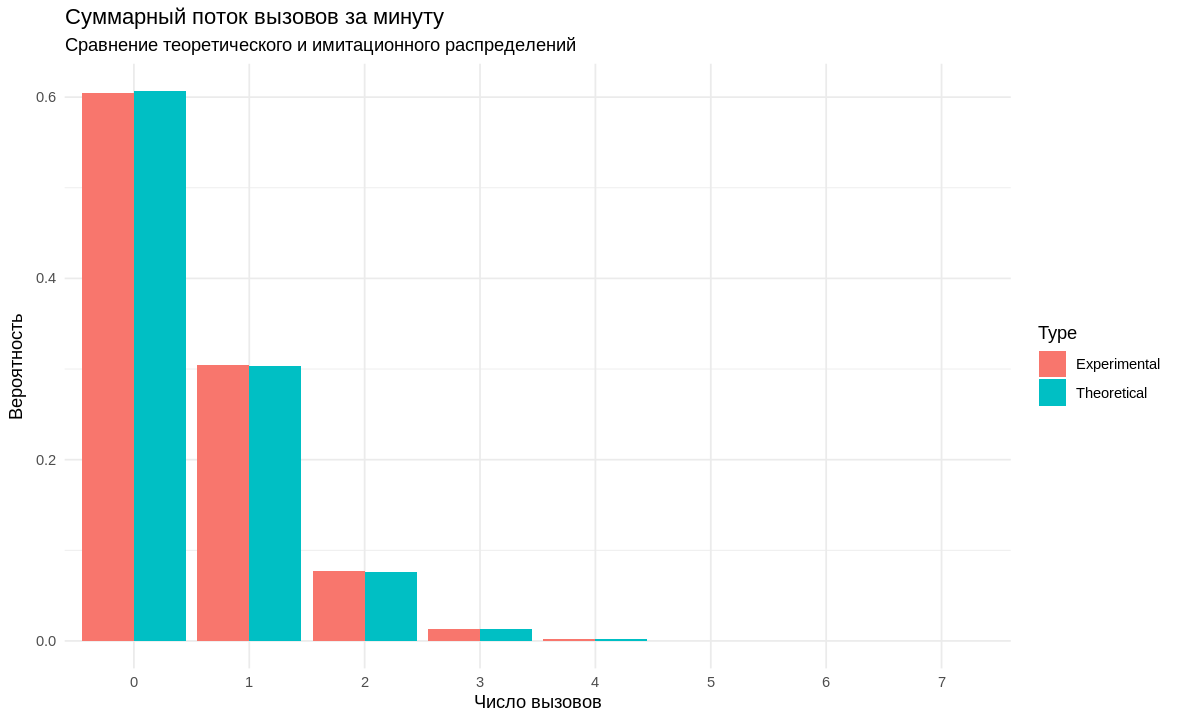

In [ ]:
k_values <- 0:max(S_sim)
dist_df <- data.frame(
  k = k_values,
  Theoretical = dpois(k_values, lambda_sum),
  Experimental = as.numeric(table(factor(S_sim, levels = k_values))) / length(S_sim)
) %>%
  pivot_longer(cols = c("Theoretical", "Experimental"), names_to = "Type", values_to = "Probability")

pS <- ggplot(dist_df, aes(x = factor(k), y = Probability, fill = Type)) +
  geom_col(position = "dodge") +
  labs(
    title = "Суммарный поток вызовов за минуту",
    subtitle = "Сравнение теоретического и имитационного распределений",
    x = "Число вызовов",
    y = "Вероятность"
  ) +
  theme_minimal()

print(pS)